In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics.tools import get_stats_fn, base_stats_dir

stats_dir = base_stats_dir
project = 'full_shape/base'
print(stats_dir/project)

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base


You can have a look at [lsstypes](https://github.com/adematti/lsstypes/tree/main/nb) notebooks.

## Holi mocks v1

### Power spectrum

In [2]:
fn = get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', version='holi-v1-altmtl', tracer='LRG',
                  zrange=(0.4, 0.6), region='GCcomb', weight='default-FKP', imock=459)
fn

PosixPath('/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v1-altmtl/mock459/mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5')

In [3]:
spectrum = types.read(fn)
print(spectrum, f"with k-average: {spectrum.get(ells=0).coords('k')}")

Mesh2SpectrumPoles(labels=[{'ells': 0}, {'ells': 2}, {'ells': 4}], size=1254) with k-average: [0.         0.00158216 0.00257437 0.00350089 0.00453571 0.005505
 0.0064685  0.00753006 0.00846034 0.00944034 0.01044992 0.01147719
 0.01251408 0.01352767 0.01452492 0.01550576 0.01650614 0.01749741
 0.01847575 0.01946183 0.02048392 0.02149681 0.02247801 0.02350894
 0.02451968 0.02548584 0.02648757 0.02749224 0.02849052 0.02948953
 0.03050037 0.03150198 0.03249394 0.03350734 0.03451511 0.03550646
 0.03650478 0.03750108 0.03850312 0.03949886 0.04049062 0.04149582
 0.04250629 0.04351068 0.04450394 0.04549905 0.04650836 0.04751106
 0.04849677 0.0494962  0.05050318 0.05150135 0.05250725 0.05350968
 0.05450168 0.05549592 0.05649516 0.0574972  0.05850652 0.05950274
 0.06050596 0.06150776 0.06250605 0.06350608 0.06450504 0.06550948
 0.06649948 0.06749584 0.06849518 0.06950311 0.07050201 0.07150105
 0.07250796 0.07350524 0.07450288 0.075505   0.07650112 0.07749599
 0.07849937 0.07950575 0.08050952 0.0

In [4]:
spectrum = spectrum.select(k=slice(0, None, 5))  # rebin to dk = 0.005 h/Mpc
spectrum = spectrum.select(k=(0., 0.4))  # select k-range
spectrum = spectrum.get(ells=[0, 2])  # monopole and quadrupole
spectrum = spectrum.at(ells=[2]).select(k=(0., 0.3))  # apply stricter k-cut to the quadrupole

for ell in spectrum.ells:
    pole = spectrum.get(ell)
    pole.coords('k')  # k-modes
    pole.value()  # value of the power spectrum multipole
    #print(pole.values('shotnoise'))  # shotnoise

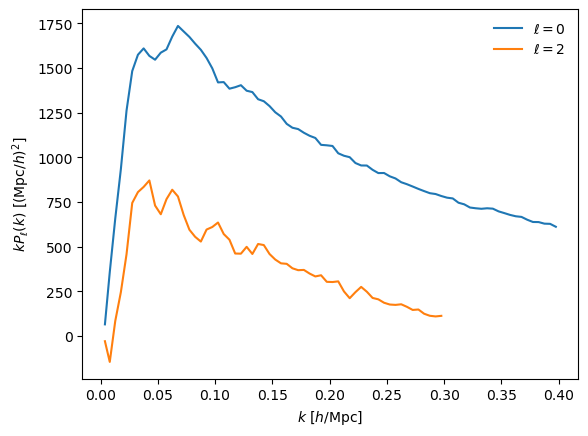

In [5]:
spectrum.plot(show=True);

### Combining NGC and SGC
The above region = GCcomb measurement is the (weighted) sum of the NGC and SGC power spectrum measurements.

In [6]:
kw = dict(project=project, version='holi-v1-altmtl', tracer='LRG', zrange=(0.4, 0.6), weight='default-FKP')
fns = [get_stats_fn(stats_dir=stats_dir, kind='mesh2_spectrum', **kw, region=region, imock=459) for region in ['NGC', 'SGC']]
combined = types.sum([types.read(fn) for fn in fns])  # also works for the bispectrum

ref = types.read(get_stats_fn(stats_dir=stats_dir, kind='mesh2_spectrum', **kw, region='GCcomb', imock=459))
assert np.allclose(combined.value(), ref.value())

### $\theta$-cut, angular upweights

In [7]:
kw = dict(project=project, version='holi-v1-altmtl', tracer='LRG', zrange=(0.4, 0.6), region='GCcomb', weight='default-FKP')
fn = get_stats_fn(stats_dir=stats_dir, kind='mesh2_spectrum', **kw, cut=True, imock=459)  # provide theta-cut or angular upweights
types.read(fn)

Mesh2SpectrumPoles(labels=[{'ells': 0}, {'ells': 2}, {'ells': 4}], size=1254)

In [8]:
# Do not forget the 'basis' argument
fn = get_stats_fn(stats_dir=stats_dir, kind='mesh3_spectrum', basis='sugiyama-diagonal', **kw, imock=459)
bispectrum = types.read(fn)
bispectrum

Mesh3SpectrumPoles(labels=[{'ells': (0, 0, 0)}, {'ells': (2, 0, 2)}], size=82)

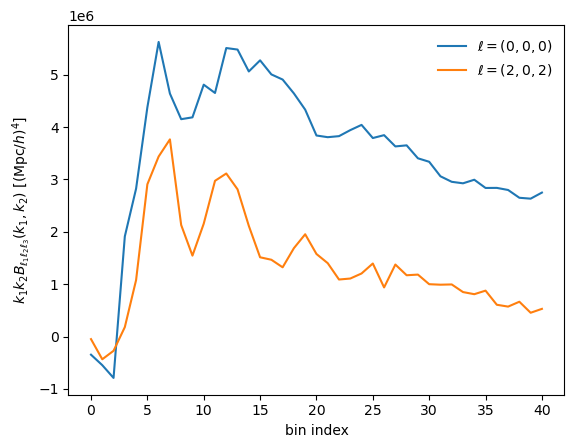

In [9]:
bispectrum.plot(show=True);

In [10]:
# All available mocks
fns = [get_stats_fn(stats_dir=stats_dir, kind='mesh2_spectrum', **kw, imock=imock) for imock in range(1000)]
fns = [fn for fn in fns if fn.exists()]
# Equivalently
fns = get_stats_fn(stats_dir=stats_dir, kind='mesh2_spectrum', **kw, imock='*')
print(len(fns))

221


In [11]:
covariance = types.cov([types.read(fn) for fn in fns])  # estimate covariance matrix

In [12]:
covariance = covariance.at.observable.match(spectrum)  # rebin to power spectrum
assert covariance.shape[0] == spectrum.size

In [13]:
covariance.value()  # to get covariance estimate

array([[ 1.35867341e+08,  5.45403273e+07,  1.06334250e+07, ...,
         2.87679775e+04,  1.24450820e+04,  1.17570715e+04],
       [ 5.45403273e+07,  6.82604869e+07,  1.73836625e+07, ...,
        -2.54363435e+04, -1.44131454e+04, -1.03174760e+04],
       [ 1.06334250e+07,  1.73836625e+07,  3.19454457e+07, ...,
        -1.04397280e+04, -2.06844154e+04, -2.13376033e+04],
       ...,
       [ 2.87679775e+04, -2.54363435e+04, -1.04397280e+04, ...,
         2.97292920e+03,  1.36847533e+03,  5.55282327e+02],
       [ 1.24450820e+04, -1.44131454e+04, -2.06844154e+04, ...,
         1.36847533e+03,  2.45723758e+03,  1.46768113e+03],
       [ 1.17570715e+04, -1.03174760e+04, -2.13376033e+04, ...,
         5.55282327e+02,  1.46768113e+03,  2.67576419e+03]],
      shape=(140, 140))

### Correlation functions (post-recon)

In [14]:
stats_dir_tmp = Path('/pscratch/sd/q/qinxunli/clustering-measurements-checks') # should be replaced when the correlation function measurements are available
fn = get_stats_fn(stats_dir=stats_dir_tmp, kind='recon_particle2_correlation', version='holi-v1-altmtl', tracer='LRG',
                  zrange=(0.4, 0.6), region='NGC', weight='default-FKP', imock=451)
fn


PosixPath('/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP_451.h5')

/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP_451.h5
Count2Correlation(labels=[{'count_names': 'DD'}, {'count_names': 'RR'}, {'count_names': 'DS'}, {'count_names': 'SD'}, {'count_names': 'SS'}], size=36000) with s-average: [  0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5  11.5
  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5  23.5
  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5  35.5
  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5  47.5
  48.5  49.5  50.5  51.5  52.5  53.5  54.5  55.5  56.5  57.5  58.5  59.5
  60.5  61.5  62.5  63.5  64.5  65.5  66.5  67.5  68.5  69.5  70.5  71.5
  72.5  73.5  74.5  75.5  76.5  77.5  78.5  79.5  80.5  81.5  82.5  83.5
  84.5  85.5  86.5  87.5  88.5  89.5  90.5  91.5  92.5  93.5  94.5  95.5
  96.5  97.5  98.5  99.5 100.5 101.5 102.5 103.5 104.5 105.5 106.5 107.5
 108.5 109.5 110.5 111.5 112

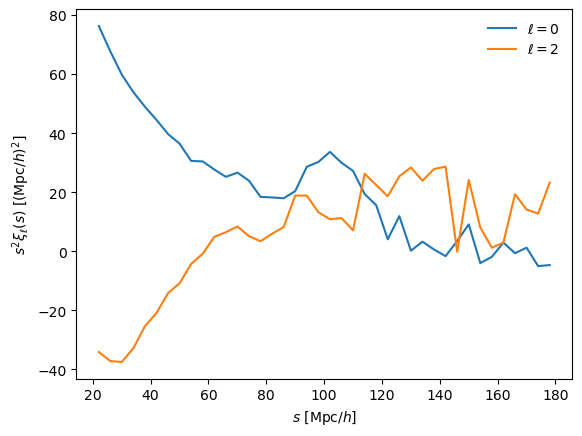

In [15]:
corr = types.read(fn)
print(fn)
print(corr, f"with s-average: {corr.get().coords('s')}")
corr = corr.select(s=slice(0, None, 4))  # rebin to ds = 4 Mpc/h
corr = corr.select(s=(20., 180))   # select s-range
xi = corr.project(ells=[0, 2])  # monopole and quadrupole
s = corr.coords('s')

for ell in xi.ells:
    pole = xi.get(ell)
    pole.coords('s')  # k-modes
    pole.value()  # value of the power spectrum multipole
    #print(pole.values('shotnoise'))  # shotnoise
xi.plot(show=True);

## Joint data vector

In [16]:
from lsstypes import ObservableTree

observables = []
for imock in range(1000):
    kw = dict(stats_dir=stats_dir, project=project, version='holi-v1-altmtl', tracer='LRG',
              zrange=(0.4, 0.6), region='GCcomb', weight='default-FKP', imock=imock)
    fn2 = get_stats_fn(kind='mesh2_spectrum', **kw)
    fn3 = get_stats_fn(kind='mesh3_spectrum', basis='sugiyama-diagonal', **kw)
    if fn2.exists():
        spectrum2, spectrum3 = types.read(fn2), types.read(fn3)
        # Can choose any observables names
        tree = ObservableTree([spectrum2, spectrum3], observables=['spectrum2', 'spectrum3'])
        observables.append(tree)

covariance = types.cov(observables)

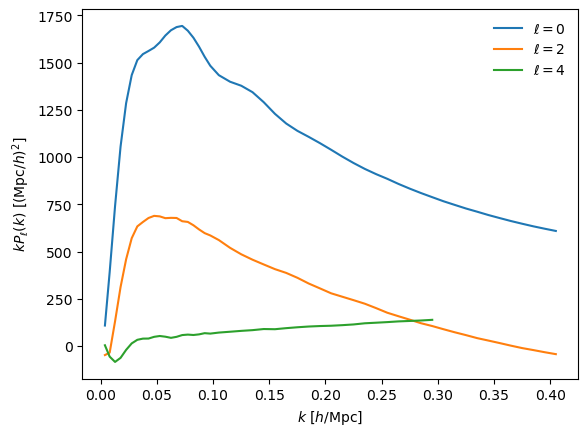

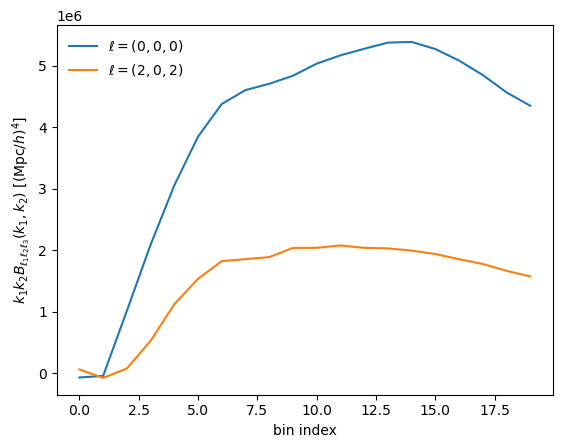

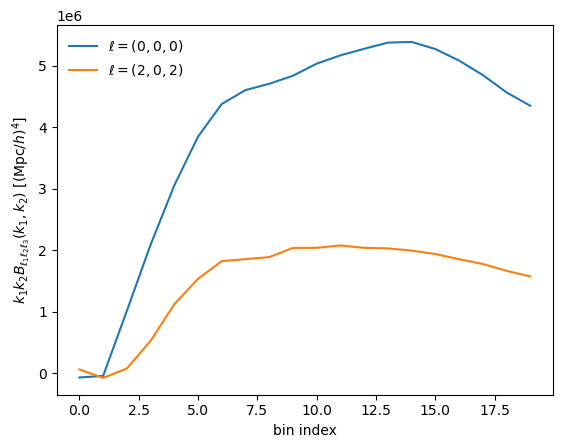

In [17]:
observable = covariance.observable
# Rebin power spectrum to dk = 0.005 h/Mpc
spectrum2 = observable.get(observables='spectrum2')
spectrum2 = spectrum2.select(k=slice(0, None, 5))
# Rebin by an extra factor 2 beyond k > 0.1 h/Mpc
for ell in spectrum2.ells:
    spectrum2 = spectrum2.at(ell).at(k=(0.1, 0.5)).select(k=slice(0, None, 2))
# Cut the hexadecapole
spectrum2 = spectrum2.at(ells=4).select(k=(0., 0.3))
# Select bispectrum
spectrum3 = observable.get(observables='spectrum3')
spectrum3 = spectrum3.select(k=(0., 0.1))
# Cut the quadrupole
spectrum3 = spectrum3.at(ells=[(2, 0, 2)]).select(k=(0., 0.1))
# Propagate to observable
observable = observable.at(observables='spectrum2').match(spectrum2)
observable = observable.at(observables='spectrum3').match(spectrum3)

observable.get(observables='spectrum2').plot(show=True)
observable.get(observables='spectrum3').plot(show=True)

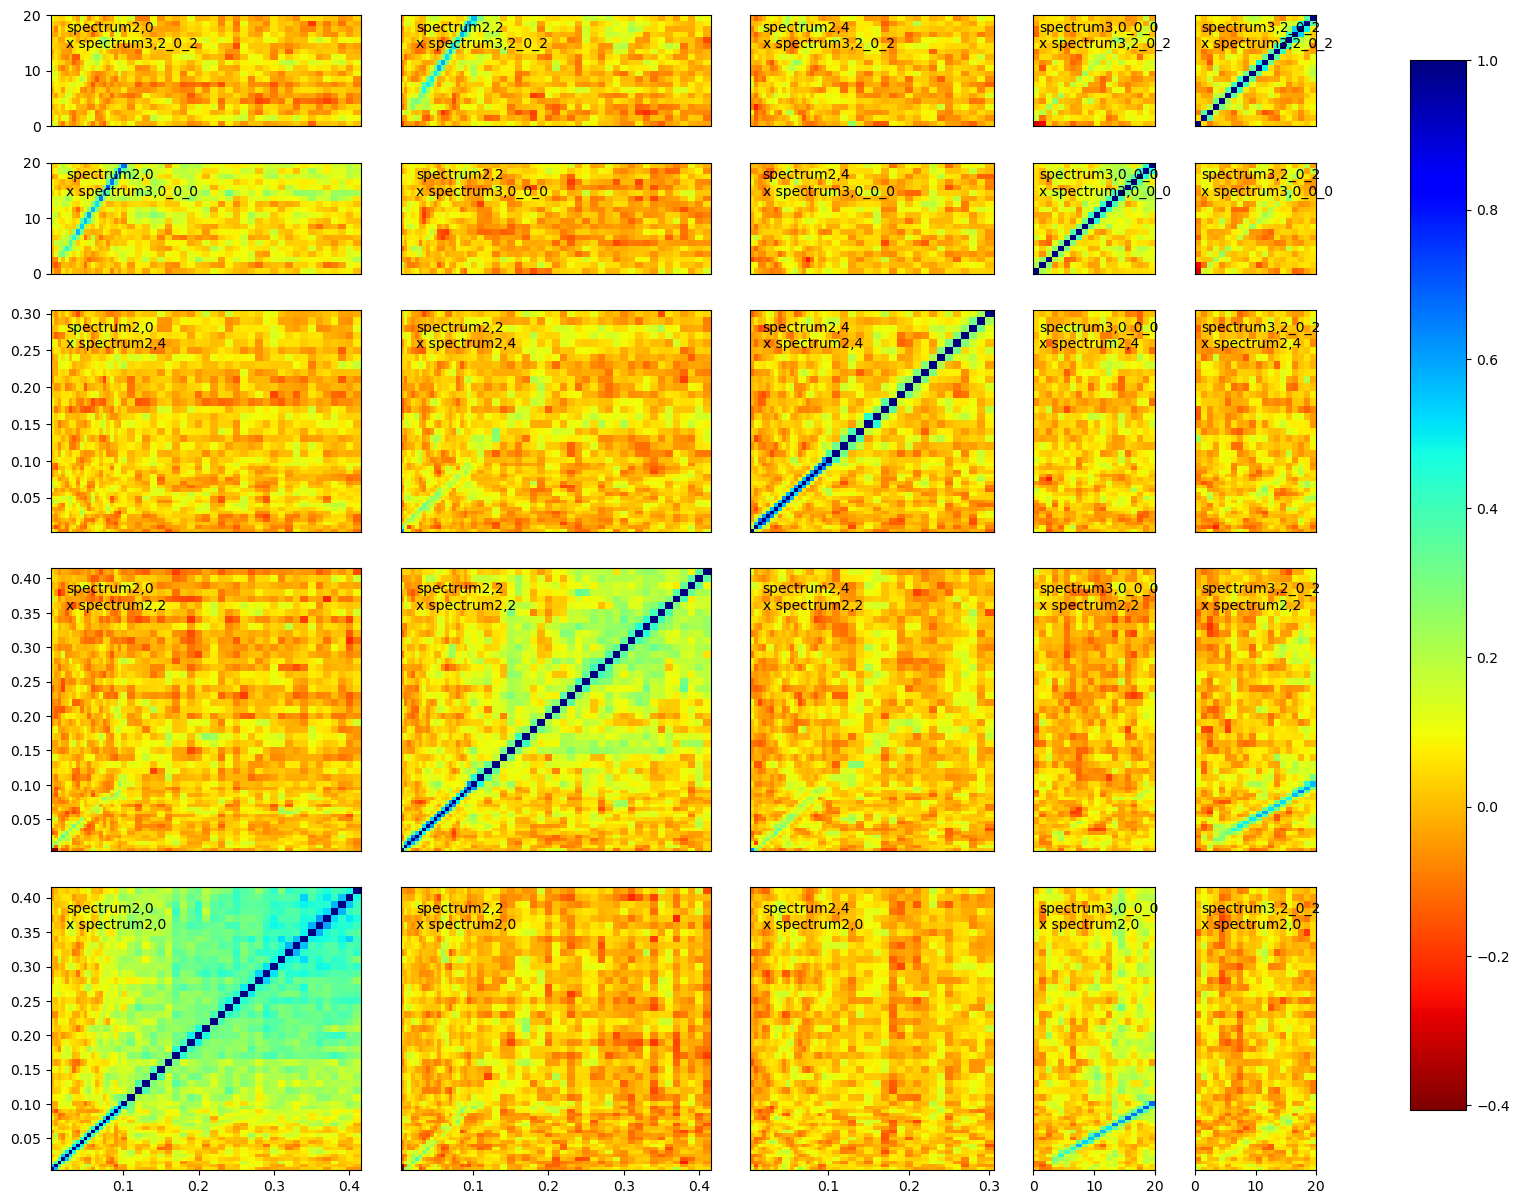

In [18]:
covariance = covariance.at.observable.match(observable)  # propagate to covariance matrix
covariance.plot(corrcoef=True, show=True);

## Abacus 2ndgen mocks

### Power spectrum

In [19]:
# 25 of them
fn = get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', version='abacus-2ndgen-complete', tracer='LRG',
                  zrange=(0.4, 0.6), region='NGC', weight='default-FKP', imock=12)

In [20]:
spectrum = types.read(fn)
# If you need 1 / nbar value for the theory
nbar = 1. / spectrum.get(0).values('shotnoise').mean()
print(f'nbar = {nbar:.3g} (h/Mpc)^3')

nbar = 0.000446 (h/Mpc)^3


In [21]:
# Window matrix
fn = get_stats_fn(stats_dir=stats_dir, project=project, kind='window_mesh2_spectrum', version='abacus-2ndgen-complete', tracer='QSO',
                  zrange=(0.8, 2.1), region='NGC', weight='default-FKP', imock=0)
window = types.read(fn)

In [22]:
window.observable

Mesh2SpectrumPoles(labels=[{'ells': 0}, {'ells': 2}, {'ells': 4}], size=1254)

In [23]:
window = window.at.observable.match(spectrum)  # match observed power spectrum
assert window.shape[0] == spectrum.size

In [24]:
window = window.at.theory.select(k=(0, 0.45))
for pole in window.theory:
    pole.coords('k')  # theory k's
window.value()  # window matrix 2D array
zeff = window.observable.get(ells=0).attrs['zeff']

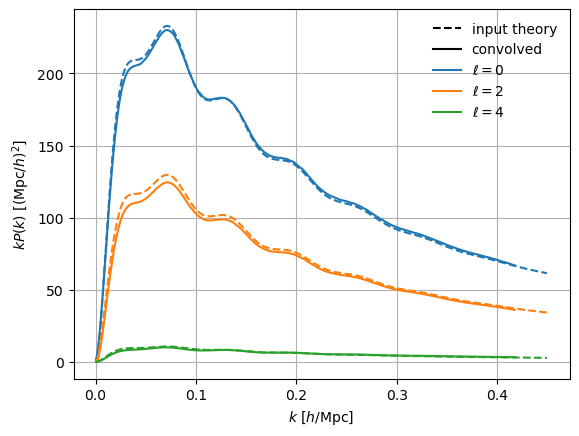

In [25]:
from cosmoprimo.fiducial import DESI

cosmo = DESI()
pk = cosmo.get_fourier().pk_interpolator().to_1d(z=zeff)
f, b = 0.8, 1.5
beta = f / b
k = window.theory.get(ells=0).coords('k')  # k's are the same for all multipoles
poles = np.array([(1. + 2. / 3. * beta + 1. / 5. * beta ** 2) * pk(k),
                  0.9 * (4. / 3. * beta + 4. / 7. * beta ** 2) * pk(k),
                  8. / 35 * beta ** 2 * pk(k)])
convolved = window.dot(np.ravel(poles), return_type=None)
# return_type = None returns a lsstype object
# To get the flattened array of multipoles
convolved_array = window.value().dot(np.ravel(poles))
# You can split it following:
convolved_poles = []
start = 0
for pole in window.observable:
    stop = start + pole.size
    convolved_poles.append(convolved_array[start:stop])
    start = stop

ax = plt.gca()
ax.plot([], [], color='k', linestyle='--', label='input theory')
ax.plot([], [], color='k', linestyle='-', label='convolved')
for ill, (label, pole) in enumerate(convolved.items()):
    ell = label['ells']
    color = f'C{ill:d}'
    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, label=rf'$\ell={ell:d}$', linestyle='-')
    ax.plot(k:=window.theory.get(ells=0).coords('k'), k * poles[ill], color=color, linestyle='--')
ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
ax.set_ylabel(r'$k P(k)$ [$(\mathrm{Mpc}/h)^2$]')
ax.legend(frameon=False)
ax.grid(True)
plt.show()

In [26]:
fn = get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', version='abacus-2ndgen-complete', tracer='LRG',
                  zrange=(0.4, 0.6), region='GCcomb', weight='default-FKP', basis='sugiyama-diagonal', imock=12)
spectrum = types.read(fn)

In [27]:
# Window matrix
fn = get_stats_fn(stats_dir=stats_dir, project=project, kind='window_mesh3_spectrum', version='abacus-2ndgen-complete', tracer='LRG',
                  zrange=(0.4, 0.6), region='GCcomb', weight='default-FKP', basis='sugiyama-diagonal', imock=0)
window = types.read(fn)

In [28]:
for pole in window.theory:
    pole.coords('k')  # theory k's
window.value()  # window matrix 2D array
zeff = window.observable.get(ells=(0, 0, 0)).attrs['zeff']

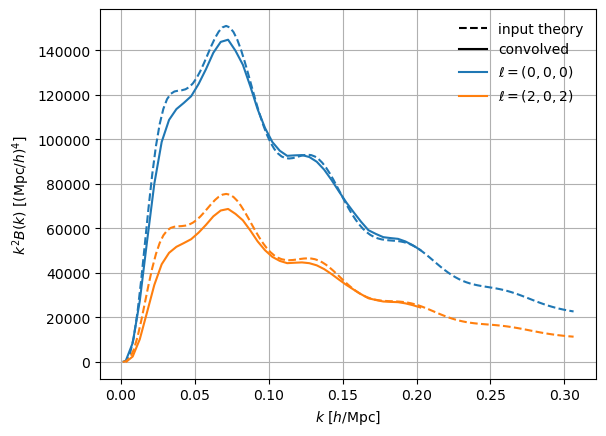

In [29]:
from cosmoprimo.fiducial import DESI

cosmo = DESI()
pk = cosmo.get_fourier().pk_interpolator().to_1d(z=zeff)
f, b = 0.8, 1.5
beta = f / b
pole = window.theory.get(ells=(0, 0, 0))
k1, k2 = pole.coords('k').T  # flattend k1, k2; same for all multipoles
# Make 2D
pole = pole.unravel()  # flattened k => k1, k2
# Dictionary of coordinates are named k1, k2
ks = pole.coords()
poles = []
# Fake theory
for ill, ell in enumerate(window.theory.ells):
    tmp = pk(ks['k1'])[:, None] * pk(ks['k2'])
    poles.append(1. / (ill + 1) * tmp.ravel())
convolved = window.dot(np.ravel(poles), return_type=None)
# return_type = None returns a lsstype object
# To get the flattened array of multipoles
convolved_array = window.value().dot(np.ravel(poles))
# You can split it following:
convolved_poles = []
start = 0
for pole in window.observable:
    stop = start + pole.size
    convolved_poles.append(convolved_array[start:stop])
    start = stop

ax = plt.gca()
ax.plot([], [], color='k', linestyle='--', label='input theory')
ax.plot([], [], color='k', linestyle='-', label='convolved')
for ill, (label, pole) in enumerate(convolved.items()):
    ell = label['ells']
    color = f'C{ill:d}'
    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, label=rf'$\ell={ell}$', linestyle='-')
    ax.plot(k:=ks['k1'], k**2 * np.diag(poles[ill].reshape(ks['k1'].size, ks['k2'].size)), color=color, linestyle='--')
ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
ax.set_ylabel(r'$k^2 B(k)$ [$(\mathrm{Mpc}/h)^4$]')
ax.legend(frameon=False)
ax.grid(True)
plt.show()